## Product-type 1 - 통계
- 데이터 로드
- 기술 통계량 확인
    - process 관련 데이터 (공정 변수)
    - sensor 관련 데이터 (환경 변수)
    - 전체 샘플 수 대비 불량률
- 정규성 검정
    - Shapiro-Wilk 검정
    - Q-Q Plot
- 등분산성 검정
    - Levene 검정
- 스피어만 상관계수 히트맵
    - process 관련 데이터 (공정 변수)
    - sensor 관련 데이터 (환경 변수)
- 전체 샘플 수 대비 불량 제품의 비율
- Box-Plot
    - 공정/환경변수 
- Welch's T-test
    - 공정/환경변수
- Mann-Whitney U 검정
    - 공정/환경변수     

In [10]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 분석/통계
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
---
### 1. 데이터 로드

In [11]:
# 1. 전처리가 완료된 Process, Sensor, Defects 관련 데이터 로드
df_process_1 = pd.read_csv('../common-file/for_process_data_product-1.csv')
df_sensor_1 = pd.read_csv('../common-file/for_sensor_data_product-1.csv')
df_defects_1 = pd.read_csv('../common-file/for_defects_data_product-1.csv')
df_original_1 = pd.read_csv('../common-file/for_entire_data_product-1.csv')

In [12]:
# 2. 데이터 크기 확인
print(f"제품 1의 전체 데이터 크기: {df_original_1.shape}")
print(f"제품 1의 전체 데이터 컬럼: {df_original_1.columns}")

print(f"제품 1의 process 관련 데이터 크기: {df_process_1.shape}")
print(f"제품 1의 process 관련 데이터 컬럼: {df_process_1.columns}")

print(f"제품 1의 sensor 관련 데이터 크기: {df_sensor_1.shape}")
print(f"제품 1의 sensor 관련 데이터 컬럼: {df_sensor_1.columns}")

print(f"제품 1의 defects 관련 데이터 크기: {df_defects_1.shape}")
print(f"제품 1의 defects 관련 데이터 컬럼: {df_defects_1.columns}")


제품 1의 전체 데이터 크기: (4207, 24)
제품 1의 전체 데이터 컬럼: Index(['shot_key', 'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
       'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
       'clamping_force', 'cycle_time', 'pressure_rise_time',
       'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
       'melting_furnace_temp', 'air_pressure', 'coolant_temp',
       'coolant_pressure', 'factory_temp', 'factory_humidity',
       'surface_defect', 'structural_defect', 'contamination_defect'],
      dtype='object')
제품 1의 process 관련 데이터 크기: (4207, 15)
제품 1의 process 관련 데이터 컬럼: Index(['shot_key', 'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
       'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
       'clamping_force', 'cycle_time', 'pressure_rise_time',
       'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time'],
      dtype='object')
제품 1의 sensor 관련 데이터 크기: (4207, 6)
제품 1의 sensor 관련 데이터 컬럼: Index(['melting_furnace_temp', 'ai

In [13]:
# 3. 불량 유무로 불량 컬럼 통일 -> is_defect 컬럼 생성
# 3-1. 행을 기준으로 1이 존재하면 불량으로 표현
defect_cols = ['surface_defect', 'structural_defect', 'contamination_defect']

# 3-2. 불량 데이터프레임
df_defects_1['is_defect'] = df_defects_1[defect_cols].max(axis=1)
# 3-3. is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_defects_1_1 = df_defects_1.drop(columns=defect_cols)

display(df_defects_1_1.head(5))

,is_defect
0,0
1,0
2,0
3,1
4,0


In [14]:
# 3-4. 전체 데이터프레임
df_original_1['is_defect'] = df_original_1[defect_cols].max(axis=1)
# 3-5. is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_original_1_1 = df_original_1.drop(columns=defect_cols)

display(df_original_1_1.head(5))

,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,is_defect
0,1_1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,26.0,2.71,32.9,58.4,0
1,1002_2,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0
2,2003_3,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0
3,3004_4,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,1
4,4005_5,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,697.9,6.4,26.1,2.69,32.9,57.8,0


In [15]:
# 3-6. 머신러닝을 위한 데이터 저장
df_original_1_1.to_csv("../common-file/ML_modeling_data_product-1.csv", index=False)

---
---
### 2. 기술통계

#### 2.1 기술통계량 및 불량율 확인

In [16]:
# 1. 기술통계
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 변수 기술통계량")
    print(f"{'='*80}\n")
    
    # 1-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 1-2. 기초 통계량
    stats_df = df_copied.describe().T
    stats_df['Skewness'] = df_copied.skew()
    
    # 1-3. 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수',
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Skewness': '왜도'
    }, inplace=True)
    
    display(stats_df)

In [17]:
create_statistics_summary(df_process_1, "process", exclude_cols="product_type" )
create_statistics_summary(df_sensor_1, "sensor")


process의 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
velocity_1,4207.0,0.143272,0.004151,0.134,0.142,0.142,0.144,0.180,4.422801
velocity_2,4207.0,0.168944,0.005202,0.162,0.168,0.168,0.170,0.212,5.413094
velocity_3,4207.0,0.182449,0.006850,0.172,0.178,0.182,0.186,0.234,3.064106
high_velocity,4207.0,2.134074,0.081259,0.000,2.120,2.137,2.152,2.285,-19.158455
cylinder_pressure,4207.0,219.793202,8.888864,107.000,215.000,217.000,218.000,241.000,-0.587423
rapid_rise_time,4207.0,0.007963,0.001266,0.000,0.008,0.008,0.008,0.021,3.769409
biscuit_thickness,4207.0,11.715237,1.529924,0.000,11.000,12.000,12.000,22.000,-1.761872
clamping_force,4207.0,255.877110,2.465235,238.000,254.000,257.000,258.000,263.000,-0.895664
cycle_time,4207.0,21.432113,6.411477,20.200,20.700,20.900,21.200,218.600,24.49784
pressure_rise_time,4207.0,0.041492,0.003257,0.000,0.041,0.043,0.044,0.046,-2.955792



sensor의 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
melting_furnace_temp,4207.0,700.388614,14.365077,671.00,689.15,701.20,710.65,730.00,0.037698
air_pressure,4207.0,6.100903,0.623627,4.60,5.80,6.20,6.60,7.10,-0.588247
coolant_temp,4207.0,26.756382,0.491092,25.90,26.40,26.70,27.10,28.10,0.628650
coolant_pressure,4207.0,2.710183,0.047140,2.59,2.69,2.72,2.75,2.79,-0.870506
factory_temp,4207.0,33.015997,1.748600,30.60,32.00,32.20,34.50,37.00,0.935854
factory_humidity,4207.0,60.528548,7.051350,45.50,57.40,62.50,65.60,70.70,-0.788468


In [18]:
# 2. 전체 샘플 수 & 불량률
total    = len(df_original_1_1)
n_defect = df_original_1_1["is_defect"].sum() # 불량제품
n_normal = total - n_defect # 정상 제품
rate     = n_defect / total * 100

print(f"=== 전체 데이터 대비 불량률 ===")
print(f"\n전체 샘플 : {total:,}개")
print(f"불량      : {int(n_defect):,}개")
print(f"정상      : {int(n_normal):,}개")
print(f"불량률    : {rate:.2f}%")

=== 전체 데이터 대비 불량률 ===

전체 샘플 : 4,207개
불량      : 739개
정상      : 3,468개
불량률    : 17.57%


#### **2.2 해석**
- 내용 추가 필요

---
---
### 3. 정규성 검정

#### 3.1 Shapiro-Wilk 검정

In [19]:
# 1. 연속형 변수 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary(df, df_name, exclude_cols=None, alpha=0.05):
    """Shapiro-Wilk 정규성 검정"""
    print(f"\n{'='*80}")
    print(f"제품 1의 {df_name} 관련 데이터 정규성 검정 (Shapiro-Wilk)")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')

    # 출력값 저장
    result_list = []

    # 각 컬럼별 정규성 검정
    for col in df_copied.columns:
        series = df_copied[col].dropna()

        # 정규성 확인: Shapiro-Wilk
        stat, p_value = stats.shapiro(series)

        # H0: 정규성을 만족한다.
        # H1: 정규성을 불만족한다.
        if p_value >= alpha:
            result = "정규성 만족"
        else:
            result = "정규성 불만족"

        # 출력값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result])

    # 출력
    shapiro_df = pd.DataFrame(
        result_list, 
        columns=[
            "변수명", 
            "Shapiro 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(shapiro_df)
    
    return shapiro_df

In [20]:
# 2. 함수 실행
shapiro_df_original_1 = create_shapiro_summary(
    df_original_1_1,
    "공정/센서",
    exclude_cols=['shot_key', 'is_defect',]
)


제품 1의 공정/센서 관련 데이터 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
velocity_1,0.569715,6.265147e-73,정규성 불만족
velocity_2,0.416442,2.610597e-79,정규성 불만족
velocity_3,0.748749,2.476649e-62,정규성 불만족
high_velocity,0.230170,2.389708e-85,정규성 불만족
cylinder_pressure,0.591752,7.414507e-72,정규성 불만족
rapid_rise_time,0.576706,1.355708e-72,정규성 불만족
biscuit_thickness,0.730327,1.119151e-63,정규성 불만족
clamping_force,0.918851,7.542148e-43,정규성 불만족
cycle_time,0.052007,4.916468e-90,정규성 불만족


#### 3.2 Q-Q Plot

In [21]:
# 1. Q-Q plot 한 번에 출력
def plot_qq_table(df, title=None, exclude_cols=None):
    """QQplot 그래프"""
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼 전체 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        # Q-Q plot
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

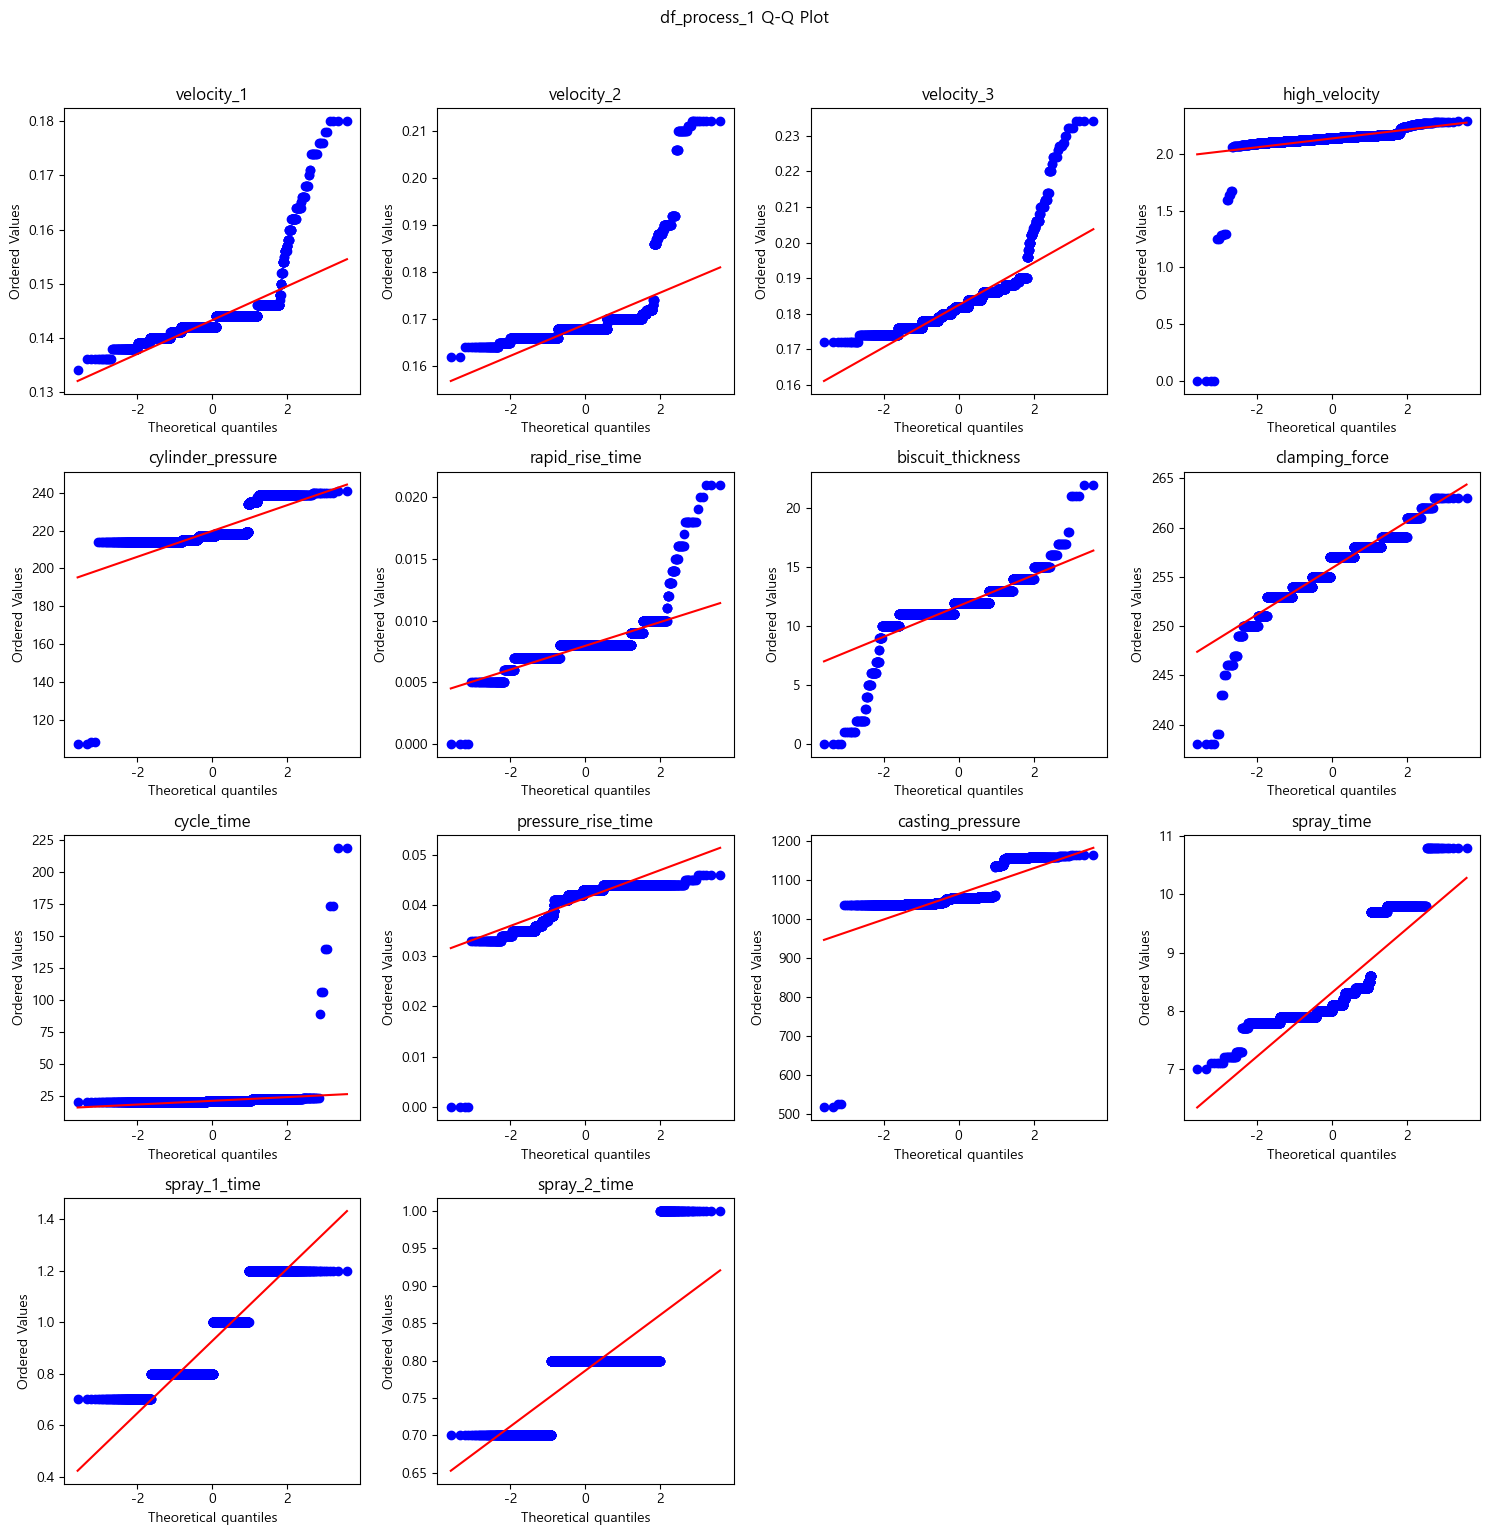

In [22]:
# 2. 함수 실행
plot_qq_table(df_process_1, 
            title="df_process_1 Q-Q Plot")

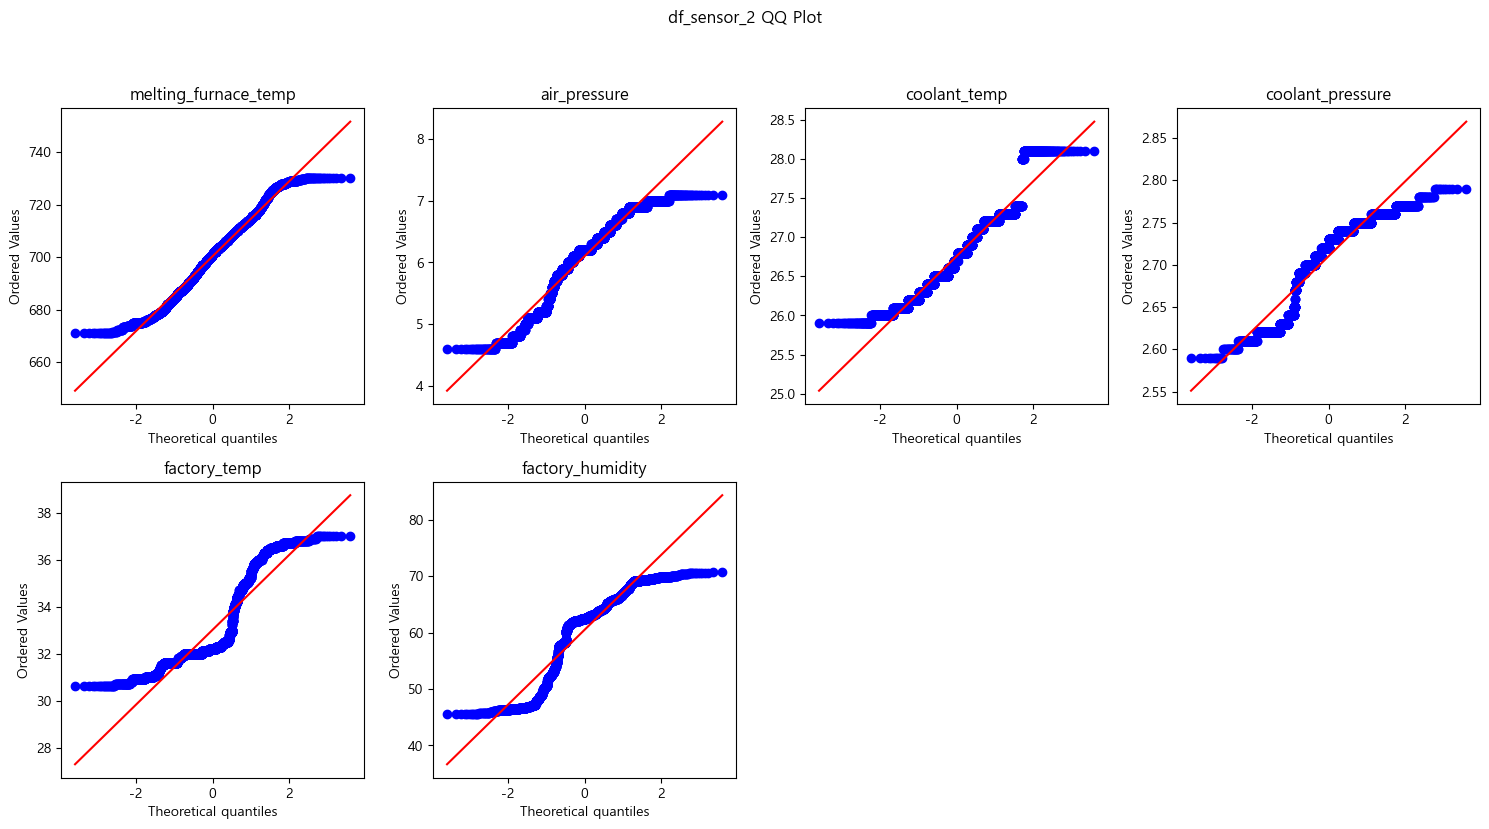

In [23]:
plot_qq_table(df_sensor_1, 
            title="df_sensor_2 QQ Plot")

#### 3.3 Levene 검증

In [24]:
from scipy.stats import levene

# 1. 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """등분산성 검정 (Levene test)"""
    print(f"\n{'='*80}")
    print(f"{df_name} 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

        
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')    
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col]

    # 출력값 저장
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
    
        # 등분산성 검정: levene
        stat, p_value = levene(group_0, group_1)

        # H0: 두 그룹의 분산이 같다 (등분산)
        # H1: 두 그룹의 분산이 다르다 (이분산)
        if p_value > alpha:
            result = "등분산 가정 가능"
        else:
            result = "등분산 가정 불가"

        # 출력 값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result
        ]
    )
    
    # 출력화면
    levene_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명", 
            "Levene 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [25]:
# 2. 함수 실행
process_levene_surface = create_levene_summary(
    df_process_1,
    df_defects_1_1,
    "is_defect",
    "df_process_1",
    exclude_cols=['shot_key']
)


df_process_1 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,21.089683,4.510936e-06,등분산 가정 불가
velocity_2,27.120408,2.003106e-07,등분산 가정 불가
velocity_3,26.808306,2.351704e-07,등분산 가정 불가
high_velocity,11.845690,5.835823e-04,등분산 가정 불가
cylinder_pressure,137.526513,2.825283e-31,등분산 가정 불가
rapid_rise_time,7.655019,5.686208e-03,등분산 가정 불가
biscuit_thickness,62.364014,3.615832e-15,등분산 가정 불가
clamping_force,51.845692,7.077913e-13,등분산 가정 불가
cycle_time,0.460697,4.973358e-01,등분산 가정 가능


In [26]:
process_levene_surface = create_levene_summary(
    df_sensor_1,
    df_defects_1_1,
    "is_defect",
    "df_sensor_1",
)


df_sensor_1 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,31.602239,2.014701e-08,등분산 가정 불가
air_pressure,153.085205,1.456104e-34,등분산 가정 불가
coolant_temp,15.763107,7.298812e-05,등분산 가정 불가
coolant_pressure,123.729716,2.391456e-28,등분산 가정 불가
factory_temp,239.109585,1.672580e-52,등분산 가정 불가
factory_humidity,153.783089,1.037631e-34,등분산 가정 불가


#### 3.4 스피어만 상관계수 히트맵

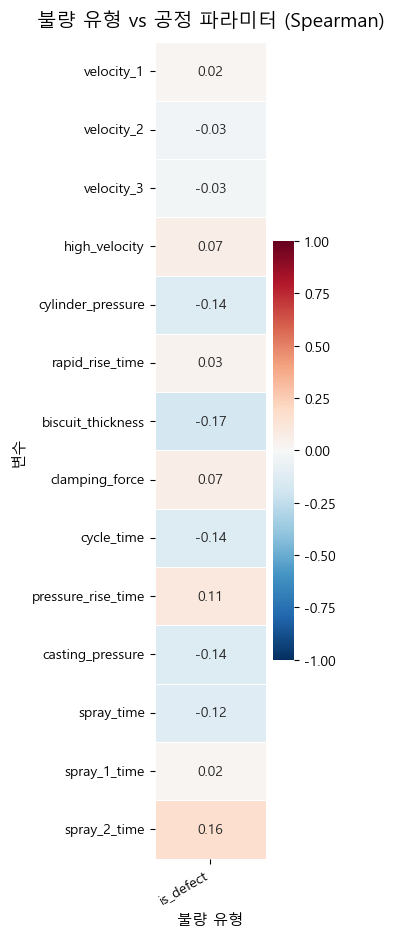

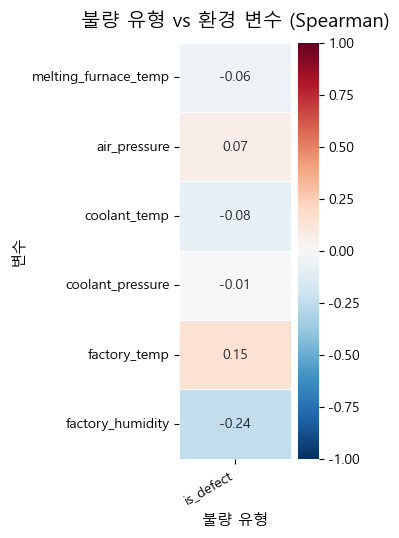

In [27]:
# 1. 변수 정의
DEFECT_COLS = ['is_defect']

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 2. 스피어만 상관계수 히트맵 시각화 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    fig, ax = plt.subplots(
        figsize=(len(defect_cols) * 1.8, len(feature_cols) * 0.65 + 1.5)
    )

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 유형', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 3. 함수 출력
plot_corr_heatmap(df_original_1_1, DEFECT_COLS, PROCESS_COLS, '불량 유형 vs 공정 파라미터 (Spearman)')
plot_corr_heatmap(df_original_1_1, DEFECT_COLS, SENSOR_COLS, '불량 유형 vs 환경 변수 (Spearman)')

#### 3.5 결측치 개수 확인
- 통계적 검정방법을 수행하기 전, 결측치 개수 확인

In [28]:
# 1. 결측치 확인
print("\n=== 전체 데이터 기준 결측치 개수 ===")
print(f"{df_original_1_1.isnull().sum().sum()}개")


=== 전체 데이터 기준 결측치 개수 ===
0개


#### 3.6 Box Plot

In [29]:
# 1. box plot 시각화 함수 정의
import math

def plot_boxplots(df, cols, group_title):
    
    # is_defect를 문자열로 변환
    df_a = df.copy()
    df_a["is_defect"] = df["is_defect"].map({0: "정상", 1: "불량"})
    
    n_rows = math.ceil(len(cols) / 4)

    fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(
            x="is_defect", y=col,
            data=df_a,
            palette={"정상": "#4C72B0", "불량": "#DD8452"},
            ax=axes[i]
        )
        axes[i].set_title(col, fontsize=11, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_xticklabels(["정상", "불량"], fontsize=10)

    # 비어있는 subplot 숨기기
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"[{group_title}] 정상 vs 불량 분포 비교", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return df_a

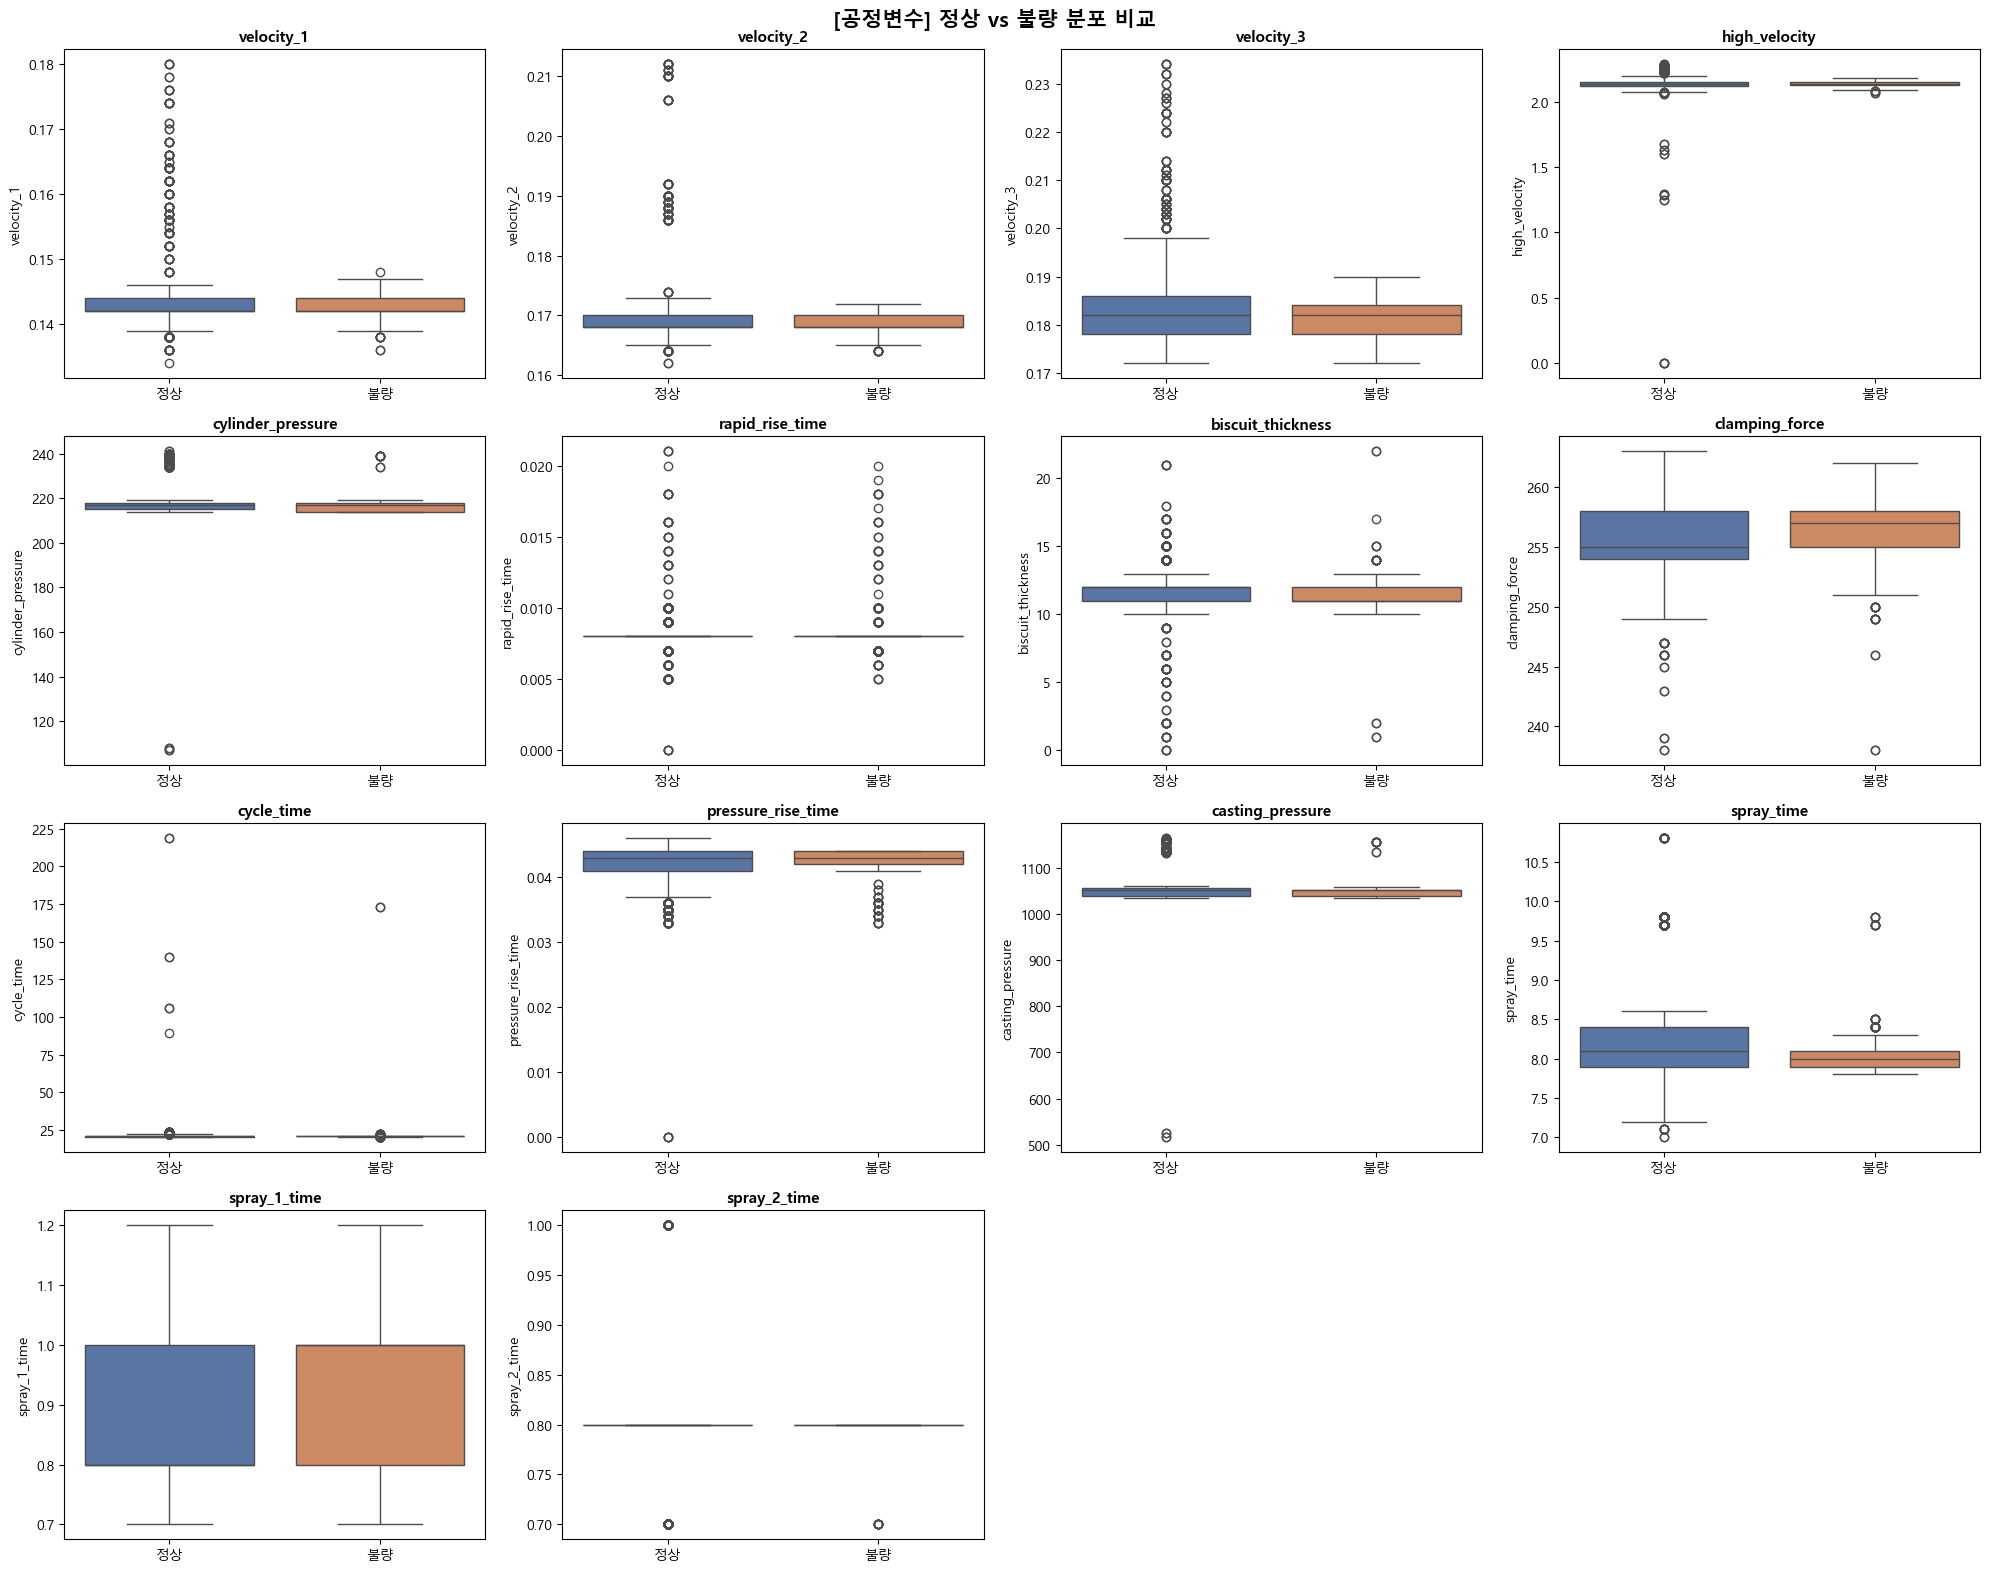

In [30]:
# 2. 함수 실행
boxplot_of_process_1 = plot_boxplots(df_original_1_1, PROCESS_COLS, "공정변수")

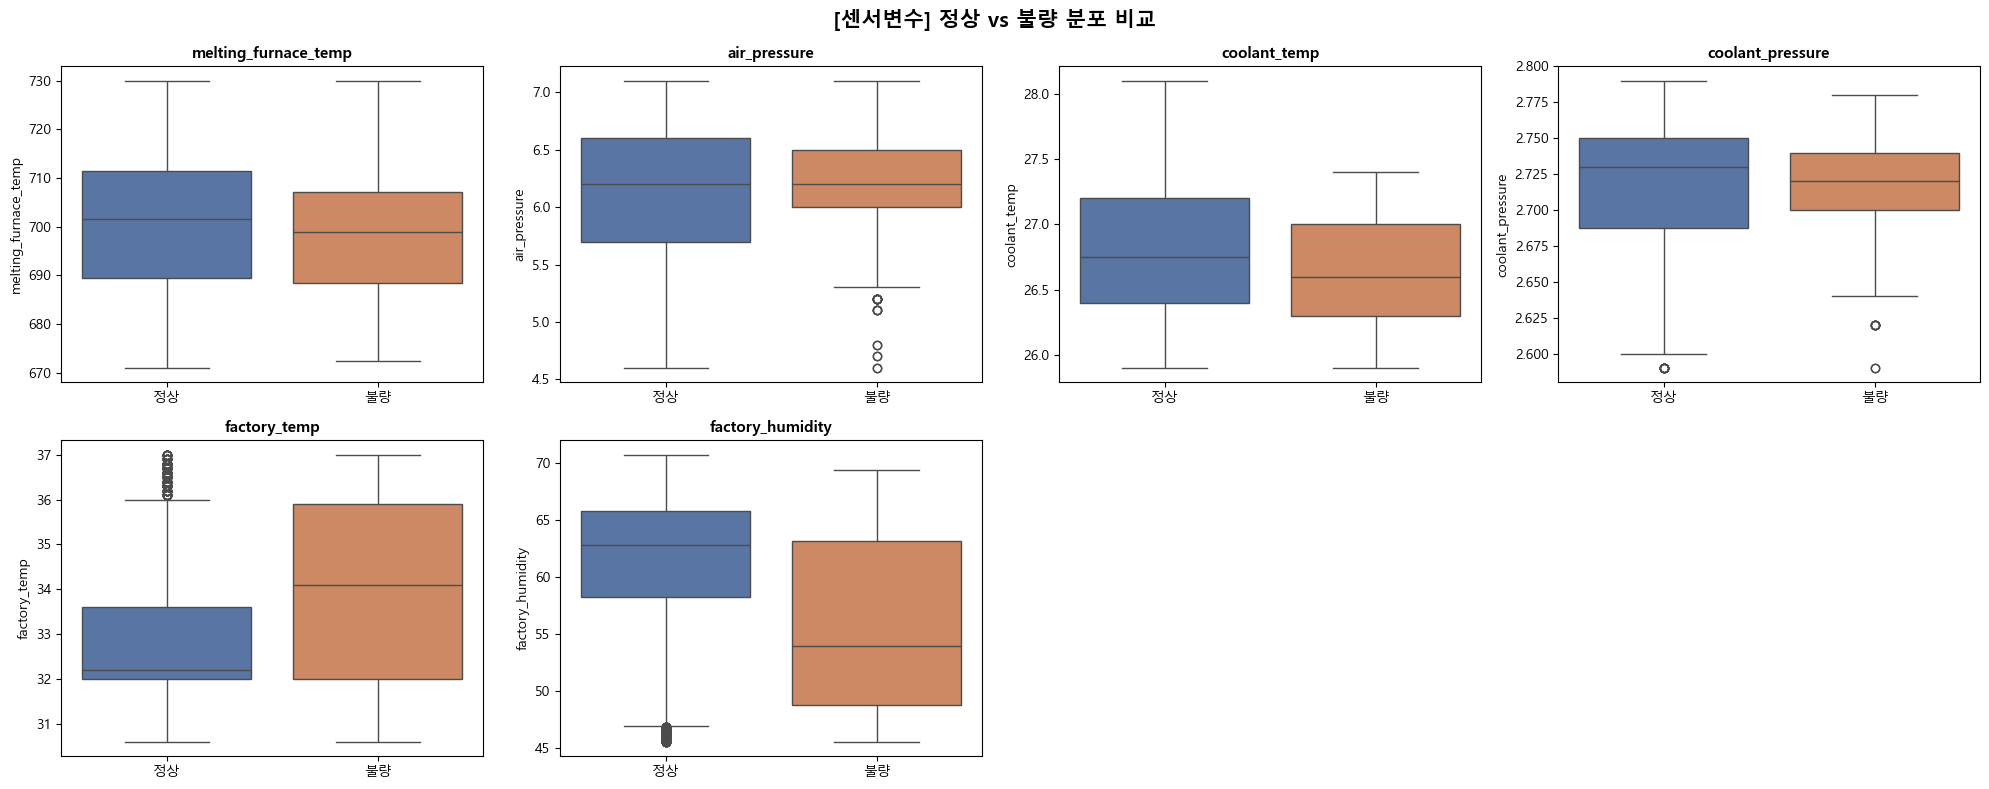

In [31]:
boxplot_of_sensor_1 = plot_boxplots(df_original_1_1, SENSOR_COLS, "센서변수")

#### **3.7 해석**
- 해석이 필요하다면 추가하시면 됩니당

---
---
### 4. 통계적 검정
#### 4.1 Welch's T-test

In [32]:
# 1. Cohen's d 효과크기 해석
def interpret_cohens_d(d):
    if d < 0.1:   
        return "매우 작음"
    elif d < 0.3: 
        return "작음"
    elif d < 0.5:
        return "중간"
    else:         
        return "큼"

In [33]:
# 2. Welch's t-test 
ALL_COLS = PROCESS_COLS + SENSOR_COLS

result = []

alpha = 0.05

for col in ALL_COLS:
    g0 = df_original_1_1.loc[df_original_1_1["is_defect"] == 0, col]
    g1 = df_original_1_1.loc[df_original_1_1["is_defect"] == 1, col]
    
    t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
    
    # Cohen's d
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d   = (g1.mean() - g0.mean()) / pooled_std
    
    result.append({
        "요인":       col,
        "정상 제품의 평균": round(g0.mean(), 4),
        "불량 제품의 평균": round(g1.mean(), 4),
        "t-통계량": round(t_stat, 4),
        "Cohen's d": round(cohens_d, 4),
        "효과크기 해석": interpret_cohens_d(abs(cohens_d)),
        "p-value": float(f"{p_val:.4e}"),
    })

df_welchs = pd.DataFrame(result)

df_welchs['통계적 유의성 여부'] = df_welchs['p-value'] < alpha

display(df_welchs)

,요인,정상 제품의 평균,불량 제품의 평균,t-통계량,Cohen's d,효과크기 해석,p-value,통계적 유의성 여부
0,velocity_1,0.1434,0.1428,5.1358,-0.1523,작음,2.998100e-07,True
1,velocity_2,0.1691,0.1681,9.6845,-0.2609,작음,6.099100e-22,True
2,velocity_3,0.1827,0.1815,6.1259,-0.2018,작음,1.094100e-09,True
3,high_velocity,2.1331,2.1384,-3.2022,0.0824,매우 작음,1.374000e-03,True
4,cylinder_pressure,220.4839,216.5521,19.9824,-0.5550,큼,2.077400e-84,True
5,rapid_rise_time,0.0079,0.0082,-3.8847,0.1723,작음,1.098400e-04,True
6,biscuit_thickness,11.7834,11.3951,7.6293,-0.2782,작음,4.375300e-14,True
7,clamping_force,255.8080,256.2016,-4.1743,0.1644,작음,3.216100e-05,True
8,cycle_time,21.4628,21.2880,0.5666,-0.0248,매우 작음,5.711300e-01,False
9,pressure_rise_time,0.0413,0.0424,-11.5147,0.3933,중간,1.394700e-29,True


#### 4.2 Mann-Whitney U 검정

In [34]:
# 1. 효과크기 해석 함수
def interpret_rbc(r):
    if r < 0.1:   
        return "매우 작음"
    elif r < 0.3: 
        return "작음"
    elif r < 0.5: 
        return "중간"
    else:         
        return "큼"

In [35]:
# 2. Mann-Whitney U
result_mwu = []
for col in ALL_COLS:
    g0 = df_original_1_1.loc[df_original_1_1["is_defect"] == 0, col]
    g1 = df_original_1_1.loc[df_original_1_1["is_defect"] == 1, col]
    
    u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    
    # Rank-biserial correlation (효과 크기)
    r_rbc = 1 - (2 * u_stat) / (len(g0) * len(g1))
    
    result_mwu.append({
        "요인":            col,
        "U-통계량":        round(u_stat, 4),
        "rank-biserial r": round(r_rbc, 4),
        "효과크기 해석": interpret_rbc(abs(r_rbc)),
        "p-value":         float(f"{p_val:.4e}"),
    })

df_mwu = pd.DataFrame(result_mwu)

df_mwu["통계적 유의성 여부"] = df_mwu["p-value"] < alpha

display(df_mwu)

,요인,U-통계량,rank-biserial r,효과크기 해석,p-value,통계적 유의성 여부
0,velocity_1,1245130.5,0.0283,매우 작음,2.065900e-01,False
1,velocity_2,1339108.0,-0.0450,매우 작음,3.873300e-02,True
2,velocity_3,1336305.0,-0.0428,매우 작음,6.569900e-02,False
3,high_velocity,1153846.0,0.0996,매우 작음,2.078600e-05,True
4,cylinder_pressure,1539452.0,-0.2014,작음,1.476000e-18,True
5,rapid_rise_time,1224530.5,0.0444,매우 작음,2.573200e-02,True
6,biscuit_thickness,1599926.0,-0.2486,작음,3.104100e-29,True
7,clamping_force,1153419.0,0.0999,매우 작음,1.435100e-05,True
8,cycle_time,1551639.0,-0.2109,작음,9.834500e-20,True
9,pressure_rise_time,1081289.5,0.1562,작음,8.391700e-12,True


#### 4.3 Rank-biserial correlation의 절댓값을 기준으로 정렬
- 내림차순으로 정렬

In [36]:
# 1. 효과크기의 절댓값을 기준으로 나열
df_mwu.sort_values('rank-biserial r', key=abs, ascending=False)

,요인,U-통계량,rank-biserial r,효과크기 해석,p-value,통계적 유의성 여부
19,factory_humidity,1752891.5,-0.3679,중간,9.742100e-56,True
6,biscuit_thickness,1599926.0,-0.2486,작음,3.104100e-29,True
18,factory_temp,988715.0,0.2284,작음,1.190100e-22,True
8,cycle_time,1551639.0,-0.2109,작음,9.834500e-20,True
10,casting_pressure,1551565.0,-0.2108,작음,1.704300e-19,True
4,cylinder_pressure,1539452.0,-0.2014,작음,1.476000e-18,True
11,spray_time,1514529.0,-0.1819,작음,3.323600e-15,True
13,spray_2_time,1057362.0,0.1749,작음,1.243900e-26,True
9,pressure_rise_time,1081289.5,0.1562,작음,8.391700e-12,True
16,coolant_temp,1434530.0,-0.1195,작음,3.002000e-07,True


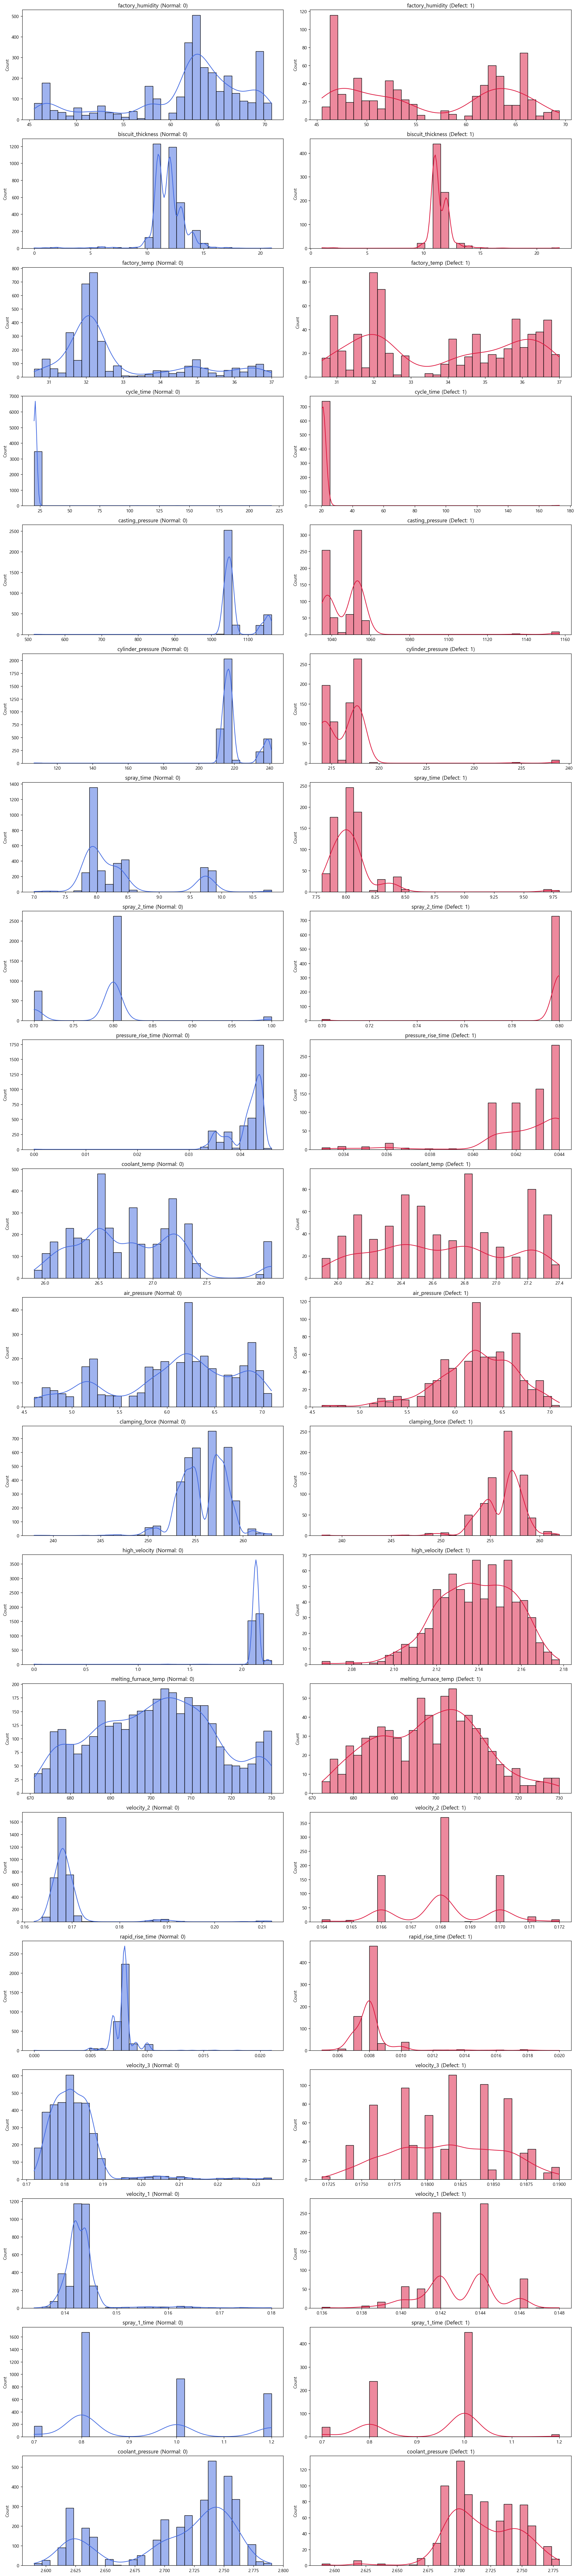

In [83]:
# 1. 효과 크기(절댓값) 기준 컬럼 정렬
df_mwu['abs_r'] = df_mwu['rank-biserial r'].abs()
sorted_cols = df_mwu.sort_values(by='abs_r', ascending=False)['요인'].tolist()

# 2. 서브플롯 설정: 행(변수 개수), 열(2개 - 정상, 불량)
n_rows = len(sorted_cols)
fig, axes = plt.subplots(n_rows, 2, figsize=(18, 4 * n_rows))

if n_rows == 1:
    axes = axes.reshape(1, 2)

for i, col in enumerate(sorted_cols):
    # --- 1열: 정상 데이터 (is_defect == 0) ---
    normal_data = df_original_1_1[df_original_1_1['is_defect'] == 0][col]
    sns.histplot(normal_data, kde=True, ax=axes[i, 0], color='royalblue', bins=30)

    r_val = df_mwu.loc[df_mwu['요인'] == col, 'rank-biserial r'].values[0]
    axes[i, 0].set_title(f'{col} (Normal: 0)', fontsize=12)
    
    # --- 2열: 불량 데이터 (is_defect == 1) ---
    defect_data = df_original_1_1[df_original_1_1['is_defect'] == 1][col]
    sns.histplot(defect_data, kde=True, ax=axes[i, 1], color='crimson', bins=30)
    axes[i, 1].set_title(f'{col} (Defect: 1)', fontsize=12)
    axes[i, 0].set_xlabel(''); axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

In [84]:
# 1. 수치형 컬럼 리스트 추출
exclude_cols = ['is_defect', 'shot_key']
stats_cols = [col for col in df_original_1_1.select_dtypes(include=['number']).columns if col not in exclude_cols]

# 2. 그룹별 기술통계량 계산
normal_desc = df_original_1_1[df_original_1_1['is_defect'] == 0][stats_cols].describe().T
defect_desc = df_original_1_1[df_original_1_1['is_defect'] == 1][stats_cols].describe().T

# 3. 차이(Difference) 분석 데이터프레임 생성
diff_analysis = pd.DataFrame(index=stats_cols)

# 평균, 표준편차, 최솟값, 최댓값에 대한 차이 계산 (정상 - 불량)
diff_analysis['mean_diff'] = normal_desc['mean'] - defect_desc['mean']
diff_analysis['std_diff'] = normal_desc['std'] - defect_desc['std']
diff_analysis['min_diff'] = normal_desc['min'] - defect_desc['min']
diff_analysis['max_diff'] = normal_desc['max'] - defect_desc['max']

# 4. 분석의 편의를 위해 '평균 차이'의 절대값 기준으로 정렬
diff_analysis['Abs_Mean_Diff'] = diff_analysis['mean_diff'].abs()
diff_analysis = diff_analysis.sort_values(by='Abs_Mean_Diff', ascending=False)

# 5. 결과 출력 (소수점 4자리)
print("--- [정상 - 불량] 통계치 차이 분석 결과 ---")
display(diff_analysis.drop(columns=['Abs_Mean_Diff']).round(4))

--- [정상 - 불량] 통계치 차이 분석 결과 ---


,mean_diff,std_diff,min_diff,max_diff
casting_pressure,18.9968,31.6698,-519.000,7.000
factory_humidity,5.3189,-1.0428,0.000,1.300
cylinder_pressure,3.9318,6.5192,-107.000,2.000
melting_furnace_temp,2.1707,2.1178,-1.400,0.000
factory_temp,-0.9837,-0.4386,0.000,0.000
clamping_force,-0.3937,0.2056,0.000,1.000
biscuit_thickness,0.3883,0.4137,-1.000,-1.000
spray_time,0.3172,0.4543,-0.800,1.000
cycle_time,0.1749,-1.8683,-0.200,45.600
air_pressure,-0.1565,0.2400,0.000,0.000


In [56]:
df_mwu.sort_values('rank-biserial r', key=abs, ascending=False).reset_index(drop=True)

,요인,U-통계량,rank-biserial r,효과크기 해석,p-value,통계적 유의성 여부
0,factory_humidity,1752891.5,-0.3679,중간,9.742100e-56,True
1,biscuit_thickness,1599926.0,-0.2486,작음,3.104100e-29,True
2,factory_temp,988715.0,0.2284,작음,1.190100e-22,True
3,cycle_time,1551639.0,-0.2109,작음,9.834500e-20,True
4,casting_pressure,1551565.0,-0.2108,작음,1.704300e-19,True
5,cylinder_pressure,1539452.0,-0.2014,작음,1.476000e-18,True
6,spray_time,1514529.0,-0.1819,작음,3.323600e-15,True
7,spray_2_time,1057362.0,0.1749,작음,1.243900e-26,True
8,pressure_rise_time,1081289.5,0.1562,작음,8.391700e-12,True
9,coolant_temp,1434530.0,-0.1195,작음,3.002000e-07,True


In [86]:
# 1. df_mwu에 절댓값 효과 크기 컬럼 추가
df_mwu['abs_r'] = df_mwu['rank-biserial r'].abs()

# 2. 두 데이터프레임 병합
combined_analysis = pd.merge(
    df_mwu, 
    diff_analysis.drop(columns=['Abs_Mean_Diff']), 
    left_on='요인', 
    right_index=True
)

# 3. 효과 크기 절댓값 기준으로 내림차순 정렬
combined_analysis = combined_analysis.sort_values(by='abs_r', ascending=False).reset_index(drop=True)

# 4. 분석에 불필요한 컬럼 제거 
final_df = combined_analysis.drop(columns=['abs_r'])

# 5. 결과 출력
print("--- [효과 크기 순] 데이터프레임 ---")
display(final_df.round(4))

--- [효과 크기 순] 데이터프레임 ---


,요인,U-통계량,rank-biserial r,효과크기 해석,p-value,통계적 유의성 여부,mean_diff,std_diff,min_diff,max_diff
0,factory_humidity,1752891.5,-0.3679,중간,0.0000,True,5.3189,-1.0428,0.000,1.300
1,biscuit_thickness,1599926.0,-0.2486,작음,0.0000,True,0.3883,0.4137,-1.000,-1.000
2,factory_temp,988715.0,0.2284,작음,0.0000,True,-0.9837,-0.4386,0.000,0.000
3,cycle_time,1551639.0,-0.2109,작음,0.0000,True,0.1749,-1.8683,-0.200,45.600
4,casting_pressure,1551565.0,-0.2108,작음,0.0000,True,18.9968,31.6698,-519.000,7.000
5,cylinder_pressure,1539452.0,-0.2014,작음,0.0000,True,3.9318,6.5192,-107.000,2.000
6,spray_time,1514529.0,-0.1819,작음,0.0000,True,0.3172,0.4543,-0.800,1.000
7,spray_2_time,1057362.0,0.1749,작음,0.0000,True,-0.0146,0.0436,0.000,0.200
8,pressure_rise_time,1081289.5,0.1562,작음,0.0000,True,-0.0011,0.0013,-0.033,0.002
9,coolant_temp,1434530.0,-0.1195,작음,0.0000,True,0.1254,0.0834,0.000,0.700


In [88]:
# 1. 기술통계량 차이 데이터(diff_analysis)와 맨-휘트니 결과(df_mwu) 병합
check_df = pd.merge(
    df_mwu[['요인', 'rank-biserial r', '효과크기 해석']], 
    diff_analysis[['mean_diff']], 
    left_on='요인', right_index=True
)

# 2. 함수
def check_direction(row):
    m_diff = row['mean_diff']
    r_val = row['rank-biserial r']
    
    if m_diff > 0 and r_val < 0:
        return "정상이 더 높음 (r 음수 일치)"
    elif m_diff < 0 and r_val > 0:
        return "불량이 더 높음 (r 양수 일치)"
    elif abs(m_diff) < 1e-6 and abs(r_val) < 1e-6: # 차이가 거의 없는 경우
        return "차이 없음"
    else:
        return "방향 불일치"

check_df['분포 위치 판정'] = check_df.apply(check_direction, axis=1)

# 3. 효과 크기(절댓값) 계산 및 정렬
check_df['abs_r'] = check_df['rank-biserial r'].abs()
result_df = check_df.sort_values(by='abs_r', ascending=False).drop(columns=['abs_r'])

# 4. 결과 출력
print("--- [효과 크기 우선순위] 방향성 체크 및 영향력 분석 ---")
display(result_df.round(4))

--- [효과 크기 우선순위] 방향성 체크 및 영향력 분석 ---


,요인,rank-biserial r,효과크기 해석,mean_diff,분포 위치 판정
19,factory_humidity,-0.3679,중간,5.3189,정상이 더 높음 (r 음수 일치)
6,biscuit_thickness,-0.2486,작음,0.3883,정상이 더 높음 (r 음수 일치)
18,factory_temp,0.2284,작음,-0.9837,불량이 더 높음 (r 양수 일치)
8,cycle_time,-0.2109,작음,0.1749,정상이 더 높음 (r 음수 일치)
10,casting_pressure,-0.2108,작음,18.9968,정상이 더 높음 (r 음수 일치)
4,cylinder_pressure,-0.2014,작음,3.9318,정상이 더 높음 (r 음수 일치)
11,spray_time,-0.1819,작음,0.3172,정상이 더 높음 (r 음수 일치)
13,spray_2_time,0.1749,작음,-0.0146,불량이 더 높음 (r 양수 일치)
9,pressure_rise_time,0.1562,작음,-0.0011,불량이 더 높음 (r 양수 일치)
16,coolant_temp,-0.1195,작음,0.1254,정상이 더 높음 (r 음수 일치)


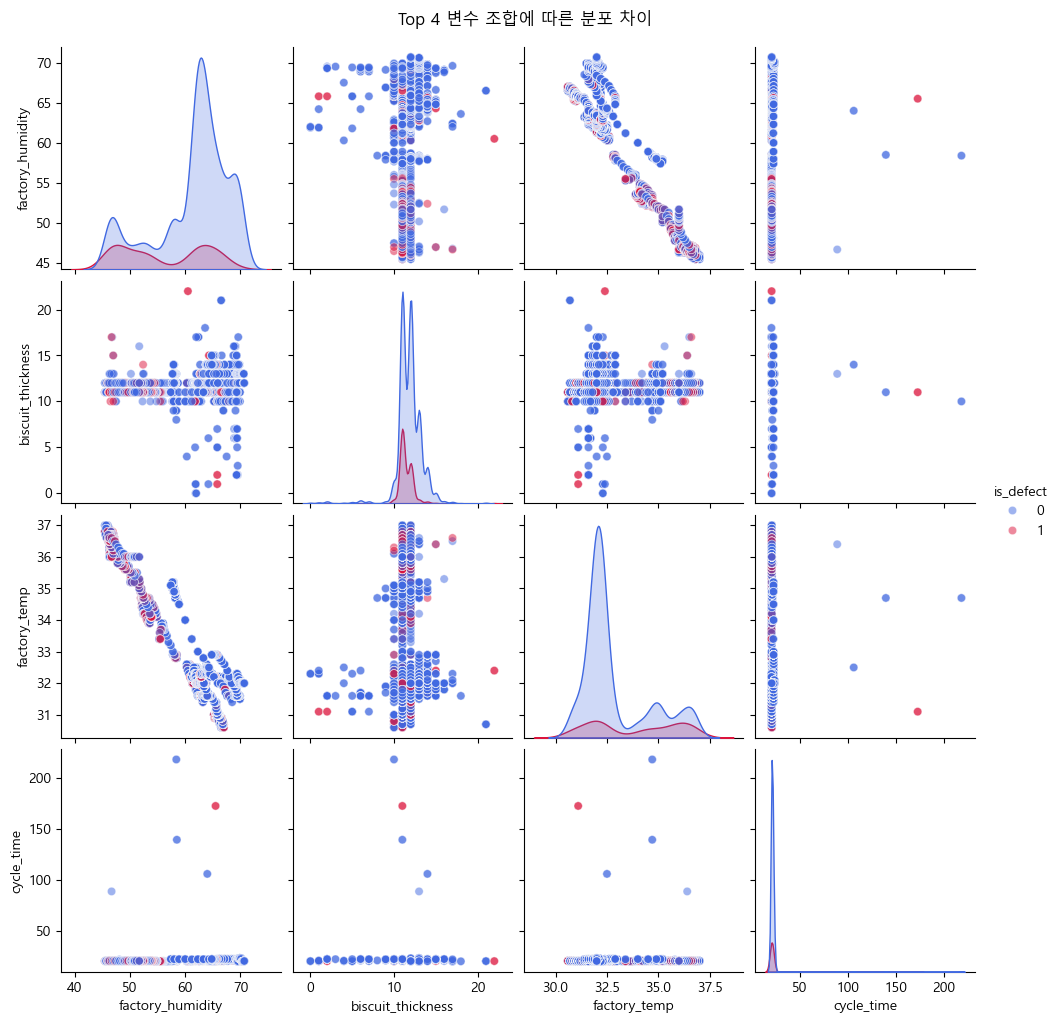

In [69]:
# 효과 크기(abs_r)가 큰 상위 4개 요인 추출
top_features = result_df.head(4)['요인'].tolist()

# 정상/불량 구분을 위해 타겟 컬럼 추가
plot_data = df_original_1_1[top_features + ['is_defect']]

# Pair Plot 그리기
sns.pairplot(plot_data, hue='is_defect', palette={0: 'royalblue', 1: 'crimson'}, 
             diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Top 4 변수 조합에 따른 분포 차이", y=1.02)
plt.show()